# Domestic Wells inside MRGCD and ABCWUA — replication

This notebook inventories domestic wells categorized as "active" in the New Mexico Office of State Engineer Point of Diversion (POD) dataset and their permitted diversions inside two administratively important geographic boundaries in New Mexico's Middle Rio Grande Valley:

- the **Middle Rio Grande Conservancy District (MRGCD)** jurisdictional area, and
- the **Albuquerque Bernalillo County Water Utility Authority (ABCWUA)** service area.

It reproduces the numbers used in the accompanying white paper and talk. The **headline result**
(OSE Points-of-Diversion vintage **2026-06-15**) is:

| Boundary | Domestic wells | Permitted diversion |
|---|--:|--:|
| **MRGCD** | **24,239** | **67,389 acre-feet/yr** |
| **ABCWUA** | **8,557** | **24,406 acre-feet/yr** |

"Domestic wells" here means **unique domestic water rights** whose point of diversion falls inside
the boundary (see the counting ladder in Step 3). The notebook prints the full ladder so a reader
can see every modeling choice and how much each one moves the number.

> **Inputs are not redistributed in this repository.** The three source shapefiles are public but
> large / third-party; `data/domestic_wells/README.md` documents exactly where to download each one
> and where to place it. This notebook unzips them from `data/domestic_wells/input/source_shapefiles/`.

## Setup

Locate the package's `data/domestic_wells` directory, define the analysis constants (the canonical
configuration, frozen 2026-07-10), and unzip the source shapefiles into a working directory.

**Requirements:** `geopandas`, `pandas`, `shapely`, `matplotlib` (Python 3.10+).

In [1]:
import warnings
warnings.filterwarnings("ignore")
import zipfile
from pathlib import Path

import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
from shapely.geometry import box

%matplotlib inline

# --- Locate the package root by walking up from the notebook ---
def find_package_root(start=None):
    cur = Path(start or Path.cwd()).resolve()
    for p in [cur, *cur.parents]:
        if (p / "data" / "domestic_wells").is_dir():
            return p
    raise FileNotFoundError("Could not find the package root (containing data/domestic_wells) above the notebook.")

PACKAGE_ROOT = find_package_root()
DOMESTIC_DIR = PACKAGE_ROOT / "data" / "domestic_wells"
SRC_ZIP_DIR  = DOMESTIC_DIR / "input" / "source_shapefiles"
WORK_DIR     = DOMESTIC_DIR / "input" / "working_unzipped"
OUTPUT_DIR   = DOMESTIC_DIR / "output"
WORK_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# --- Canonical analysis constants (frozen 2026-07-10) ---
DOM_CODES    = ["DOM", "DOL", "PDM", "DCN"]  # OSE domestic use codes
STACK_THRESH = 10        # >= 10 co-located wells + null qtr_4th  => confirmed PLSS-centroid stack
HALF_SEC     = 804.67    # half a US survey mile, metres: PLSS section-square half-width
CHART_START, CHART_END = 1950, 2025

# Print a repo-relative path (not machine-specific) to confirm the location resolved.
print("Package data directory:", DOMESTIC_DIR.relative_to(PACKAGE_ROOT))

Package data directory: data/domestic_wells


In [2]:
# Unzip the three source archives (idempotent: skips if already extracted).
# Each archive is flat (shapefile sidecars at the root of the zip).
ARCHIVES = {
    "OSE_PODs.zip":                      ("OSE_PODs",                      "Points_of_Diversion.shp"),
    "MRGCD-Jurisdictional-Boundary.zip": ("MRGCD-Jurisdictional-Boundary", "MRGCD_Jurisdictional_Area.shp"),
    "ABCWUAServiceArea.zip":             ("ABCWUAServiceArea",             "ABCWUAServiceArea.shp"),
}

shp_paths = {}
for archive, (folder, shp) in ARCHIVES.items():
    dest = WORK_DIR / folder
    shp_path = dest / shp
    if not shp_path.exists():
        zip_path = SRC_ZIP_DIR / archive
        if not zip_path.exists():
            raise FileNotFoundError(
                f"Missing source archive: {zip_path}\n"
                f"See data/domestic_wells/README.md for where to download and place it."
            )
        dest.mkdir(parents=True, exist_ok=True)
        with zipfile.ZipFile(zip_path) as zf:
            zf.extractall(dest)
    shp_paths[folder] = shp_path

POD_SHP    = shp_paths["OSE_PODs"]
MRGCD_SHP  = shp_paths["MRGCD-Jurisdictional-Boundary"]
ABCWUA_SHP = shp_paths["ABCWUAServiceArea"]

pd.DataFrame(
    {"shapefile": [str(p.relative_to(DOMESTIC_DIR)) for p in shp_paths.values()],
     "exists":    [p.exists() for p in shp_paths.values()]}
)

,shapefile,exists
0,input/working_unzipped/OSE_PODs/Points_of_Dive...,True
1,input/working_unzipped/MRGCD-Jurisdictional-Bo...,True
2,input/working_unzipped/ABCWUAServiceArea/ABCWU...,True


## Step 1 — Load the Points of Diversion and select active domestic wells

The OSE Points of Diversion (POD) layer is every permitted well and surface diversion in New Mexico.
We keep rows that are **active** (`pod_status == "ACT"`) and carry a **domestic use code**
(`DOM`, `DOL`, `PDM`, `DCN`).

> **Location-quality caveat.** A majority of OSE POD coordinates are **not** field-measured — they are
> dropped at the centroid of the PLSS legal description (accurate to the ~40–160 acre cell, not to the
> well). Many distinct wells therefore **stack** on one coordinate. We do not use raw coordinates for
> parcel-level claims; the only spatial test here is **point-in-boundary**, and Step 3 explicitly
> handles the boundary-ambiguous PLSS stacks.

In [3]:
pods = gpd.read_file(POD_SHP)
print(f"POD layer: {len(pods):,} features   CRS: {pods.crs}")
print(f"Boundaries will be reprojected to the POD CRS ({pods.crs.to_epsg()}) for all spatial tests.")

POD layer: 278,408 features   CRS: EPSG:26913
Boundaries will be reprojected to the POD CRS (26913) for all spatial tests.


## Step 2 — Load the two boundaries

Each boundary is reprojected to the POD coordinate system and dissolved to a single geometry.

- **MRGCD** — the district's jurisdictional area (static 2008 OSE/MRGCD layer, 6 polygons).
- **ABCWUA** — the service-area polygon from the **OSE** "New Mexico Public Water System Boundaries"
  layer (`ABCWUAServiceArea.shp`). This is the state regulator's PWS footprint.

> **ABCWUA boundary is provisional.** The OSE PWS polygon and ABCWUA's own "Know Your Zone" map
> disagree by roughly ~1,200 domestic rights. The white paper uses the OSE polygon as the more
> conservative footprint and flags it as provisional. See `data/domestic_wells/README.md`.

In [4]:
mrgcd_boundary  = gpd.read_file(MRGCD_SHP).to_crs(pods.crs).union_all()
abcwua_boundary = gpd.read_file(ABCWUA_SHP).to_crs(pods.crs).union_all()

pd.DataFrame({
    "boundary":   ["MRGCD", "ABCWUA"],
    "area_acres": [round(mrgcd_boundary.area / 4046.8564224, 1),
                   round(abcwua_boundary.area / 4046.8564224, 1)],
})

,boundary,area_acres
0,MRGCD,280616.2
1,ABCWUA,119462.2


## Step 3 — The counting ladder

We count in four steps ("rungs"). Each rung is a defensible number; the differences between them are
the modeling choices, made explicit.

1. **Active domestic PODs** — every active domestic point of diversion inside the boundary.
2. **Physical well locations** — drop OSE **administrative** records (`CLW` change-of-location
   filings and `-X` administrative suffixes) that are not new wells on the ground.
3. **Unique water rights**  ★ **CANONICAL** — deduplicate multiple wellheads of one right to the
   base right (`RG-NNNNN`), and count each right's permitted diversion **once** (a right's AF is
   shared across its `-POD2 / -POD3` wellheads, so we take the max `total_div` over the right).
   *This is the headline number.*
4. **Unique rights, solidly inside** — a robustness check. Where a confirmed **PLSS-centroid stack**
   (≥ 10 wells sharing one coordinate, no quarter-quarter refinement) sits near the boundary, its
   ~1-square-mile section could straddle the line. This rung drops those **boundary-ambiguous**
   stacks. It is reported for transparency, **not** as the headline — it shows the headline barely
   moves without them.

In [5]:
def add_stack_n(gdf):
    "Count PODs sharing an exact coordinate (rounded to 0.1 m) — the PLSS-stacking signal."
    pairs = list(zip(gdf.geometry.x.round(1), gdf.geometry.y.round(1)))
    counts = pd.Series(pairs).value_counts()
    out = gdf.copy()
    out["stack_n"] = [counts[p] for p in pairs]
    return out


def domestic_in(boundary_geom):
    "Active domestic PODs whose location falls inside the boundary."
    clipped = gpd.clip(pods, boundary_geom)
    active = clipped[clipped["pod_status"] == "ACT"]
    return active[active["use_"].isin(DOM_CODES)].copy()


def counting_ladder(dom, boundary_geom, label):
    "Return the four-rung counting ladder for one boundary."
    dom = dom.copy()
    dom["pod_base"] = dom["pod_file"].str.extract(r"^([A-Z]+-\d+)", expand=False)
    dom["is_admin"] = (
        dom["pod_file"].str.contains("CLW", na=False)
        | dom["pod_file"].str.contains(r"-X(-|$)", regex=True, na=False)
    )
    dom = add_stack_n(dom)

    # rung 1 — all active domestic PODs
    n_all, af_all = len(dom), dom["total_div"].sum()

    # rung 2 — physical wells (administrative records removed)
    phys = dom[~dom["is_admin"]]
    n_phys, af_phys = len(phys), phys["total_div"].sum()

    # rung 3 — unique water rights (CANONICAL): dedup to base right, AF once per right
    n_rights = phys["pod_base"].nunique()
    af_rights = phys.groupby("pod_base")["total_div"].max().sum()

    # rung 4 — solidly inside: drop boundary-ambiguous PLSS-centroid stacks
    plss = dom[dom["qtr_4th"].isna() & (dom["stack_n"] >= STACK_THRESH)].copy()
    plss["square_inside"] = plss.geometry.apply(
        lambda g: box(g.x - HALF_SEC, g.y - HALF_SEC,
                      g.x + HALF_SEC, g.y + HALF_SEC).within(boundary_geom)
    )
    near_edge_idx = plss[~plss["square_inside"]].index
    solid = dom[~dom.index.isin(near_edge_idx) & ~dom["is_admin"]]
    solid_rights = solid.groupby("pod_base")["total_div"].max()

    return {
        "boundary": label,
        "active_domestic_pods": n_all,
        "active_domestic_af": round(af_all),
        "physical_wells": n_phys,
        "physical_af": round(af_phys),
        "unique_rights": n_rights,                 # <- CANONICAL headline (wells)
        "unique_rights_af": round(af_rights),      # <- CANONICAL headline (AF)
        "solidly_inside_rights": len(solid_rights),
        "solidly_inside_af": round(solid_rights.sum()),
        "near_edge_pods_excluded": len(near_edge_idx),
    }

In [6]:
ladder = pd.DataFrame([
    counting_ladder(domestic_in(mrgcd_boundary), mrgcd_boundary, "MRGCD"),
    counting_ladder(domestic_in(abcwua_boundary), abcwua_boundary, "ABCWUA"),
]).set_index("boundary")

ladder.T

boundary,MRGCD,ABCWUA
active_domestic_pods,28343,9406
active_domestic_af,78448,26690
physical_wells,28150,9329
physical_af,77879,26463
unique_rights,24239,8557
unique_rights_af,67389,24406
solidly_inside_rights,22916,7901
solidly_inside_af,63477,22465
near_edge_pods_excluded,1433,719


## Step 4 — Validate against the published (canonical) numbers

The headline is **rung 3, unique water rights**. Because this notebook uses the same POD vintage
(2026-06-15) and the same boundaries as the white paper, it should reproduce the published figures
**exactly**.

In [7]:
CANONICAL_TARGETS = {
    "MRGCD":  {"unique_rights": 24239, "unique_rights_af": 67389},
    "ABCWUA": {"unique_rights":  8557, "unique_rights_af": 24406},
}

checks = []
for b, tgt in CANONICAL_TARGETS.items():
    got_w  = int(ladder.loc[b, "unique_rights"])
    got_af = int(ladder.loc[b, "unique_rights_af"])
    checks.append({
        "boundary": b,
        "wells": got_w, "target_wells": tgt["unique_rights"], "d_wells": got_w - tgt["unique_rights"],
        "af": got_af, "target_af": tgt["unique_rights_af"], "d_af": got_af - tgt["unique_rights_af"],
        "match": got_w == tgt["unique_rights"] and got_af == tgt["unique_rights_af"],
    })
check_df = pd.DataFrame(checks).set_index("boundary")
assert check_df["match"].all(), "Replication does not match the canonical numbers — investigate."
print("All boundaries reproduce the canonical numbers exactly.")
check_df

All boundaries reproduce the canonical numbers exactly.


,wells,target_wells,d_wells,af,target_af,d_af,match
boundary,,,,,,,
MRGCD,24239,24239,0,67389,67389,0,True
ABCWUA,8557,8557,0,24406,24406,0,True


## Step 5 — Cumulative permitted diversion over time

Each unique water right is placed at the **earliest completion year** across its wellheads, with its
permitted diversion counted once. Rights with no parseable completion date, or dated outside
1950–2025, are excluded from the curve but reconciled to the headline total below.

In [8]:
def annual_rights(dom, label):
    "One row per unique right: earliest completion year + permitted AF (once per right)."
    dom = dom.copy()
    dom["pod_base"] = dom["pod_file"].str.extract(r"^([A-Z]+-\d+)", expand=False)
    dom["is_admin"] = (
        dom["pod_file"].str.contains("CLW", na=False)
        | dom["pod_file"].str.contains(r"-X(-|$)", regex=True, na=False)
    )
    phys = dom[~dom["is_admin"]].copy()
    phys["year"] = pd.to_datetime(phys["finish_dat"], errors="coerce").dt.year
    rights = phys.groupby("pod_base").agg(year=("year", "min"), af=("total_div", "max"))

    n_total, af_total = len(rights), rights["af"].sum()
    dated = rights[(rights["year"] >= CHART_START) & (rights["year"] <= CHART_END)]
    n_undated, af_undated = n_total - len(dated), af_total - dated["af"].sum()

    idx = pd.RangeIndex(CHART_START, CHART_END + 1, name="year")
    new_rights = dated.groupby("year").size().reindex(idx, fill_value=0)
    new_af = dated.groupby("year")["af"].sum().reindex(idx, fill_value=0)
    ts = pd.DataFrame({
        "boundary": label, "year": idx,
        "new_rights": new_rights.values, "new_af": new_af.values.round(1),
        "cumulative_rights": new_rights.cumsum().values,
        "cumulative_af": new_af.cumsum().values.round(1),
    })
    print(f"{label}: dated-curve endpoint {int(ts['cumulative_rights'].iloc[-1]):,} rights / "
          f"{ts['cumulative_af'].iloc[-1]:,.0f} AF  +  {n_undated:,} undated ({af_undated:,.0f} AF)  "
          f"=  total {n_total:,} rights / {af_total:,.0f} AF")
    return ts

ts_mrgcd  = annual_rights(domestic_in(mrgcd_boundary), "MRGCD")
ts_abcwua = annual_rights(domestic_in(abcwua_boundary), "ABCWUA")
timeseries = pd.concat([ts_mrgcd, ts_abcwua], ignore_index=True)

MRGCD: dated-curve endpoint 23,155 rights / 64,573 AF  +  1,084 undated (2,816 AF)  =  total 24,239 rights / 67,389 AF
ABCWUA: dated-curve endpoint 8,252 rights / 23,634 AF  +  305 undated (772 AF)  =  total 8,557 rights / 24,406 AF


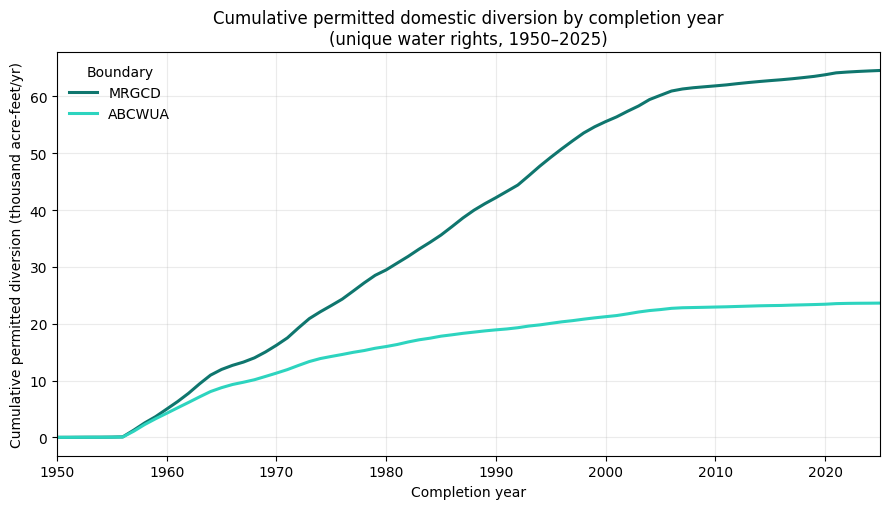

In [9]:
fig, ax = plt.subplots(figsize=(9, 5.2))
colors = {"MRGCD": "#0f766e", "ABCWUA": "#2dd4bf"}
for label, ts in [("MRGCD", ts_mrgcd), ("ABCWUA", ts_abcwua)]:
    ax.plot(ts["year"], ts["cumulative_af"] / 1000, label=label, color=colors[label], linewidth=2.2)

ax.set_title("Cumulative permitted domestic diversion by completion year\n(unique water rights, 1950–2025)")
ax.set_xlabel("Completion year")
ax.set_ylabel("Cumulative permitted diversion (thousand acre-feet/yr)")
ax.legend(title="Boundary", frameon=False)
ax.grid(True, alpha=0.25)
ax.set_xlim(CHART_START, CHART_END)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "cumulative_permitted_diversion.png", dpi=150)
plt.show()

## Step 6 — Write derived outputs

The counting ladder and the annual time series are written to `data/domestic_wells/output/` as CSVs
(regenerated on every run; not committed by default).

In [10]:
ladder.to_csv(OUTPUT_DIR / "domestic_wells_counting_ladder.csv")
timeseries.to_csv(OUTPUT_DIR / "domestic_wells_cumulative_time_series.csv", index=False)
print("Wrote:")
for f in ["domestic_wells_counting_ladder.csv",
          "domestic_wells_cumulative_time_series.csv",
          "cumulative_permitted_diversion.png"]:
    print("  data/domestic_wells/output/" + f)

Wrote:
  data/domestic_wells/output/domestic_wells_counting_ladder.csv
  data/domestic_wells/output/domestic_wells_cumulative_time_series.csv
  data/domestic_wells/output/cumulative_permitted_diversion.png


## Notes and caveats

- **Definition.** The headline counts **unique domestic water rights** (rung 3), not raw POD rows.
  One right can have several wellheads; its permitted diversion is counted once.
- **Permitted, not consumed.** `total_div` is the **permitted** annual diversion on the right — an
  administrative ceiling, not measured pumping or consumptive use.
- **ABCWUA boundary is provisional** (OSE PWS polygon vs. ABCWUA's own service-zone map differ by
  ~1,200 rights). See `data/domestic_wells/README.md`.
- **POD location quality.** Most coordinates are PLSS-cell centroids, not field GPS. This notebook
  only ever tests point-in-boundary and explicitly handles boundary-ambiguous PLSS stacks (rung 4);
  it makes no parcel-level claims.
- **Vintage.** Numbers above are for OSE POD vintage **2026-06-15**. A newer POD download will shift
  the counts; re-run the notebook to regenerate.